# Install dan Import Library

In [1]:
!pip install numpy==1.24.4 --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 60.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.24.4 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.24.4 which is incompatible.
blosc2 3.3.1 requires numpy>=1.26, but you have numpy 1.24.4 which is 

In [1]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2505210 sha256=97f7ffb18607d21cc6446181c7e0336674009cdfb8a798a42da502b6823a43bd
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [2]:
# Import Library
import kagglehub
import pandas as pd
import os
import random
import operator
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import sys
from surprise import Dataset, Reader, accuracy, NMF, SlopeOne, CoClustering
from surprise.model_selection import train_test_split, GridSearchCV
from surprise.dataset import DatasetAutoFolds
from collections import defaultdict

Install dan Import library ini sengaja dikelompokan untuk mengetahui apa saja yang dibutuhkan dalam project ini.

# Data Understanding

In [3]:
# Download latest version
path = kagglehub.dataset_download("aprabowo/indonesia-tourism-destination")

datafile = os.listdir(path)
datafile

['user.csv',
 'tourism_rating.csv',
 'package_tourism.csv',
 'tourism_with_id.csv']

Mengunduh dataset yang akan digunakan pada project. Adapun datasetnya berasal dari Kaggle yang bernama [Indonesia Tourism Destination](https://www.kaggle.com/datasets/aprabowo/indonesia-tourism-destination)

In [5]:
places = pd.read_csv(path + '/tourism_with_id.csv')
ratings = pd.read_csv(path + '/tourism_rating.csv')

print("Jumlah Profil Pengguna: ", len(ratings.User_Id.unique()))
print("Jumlah Tempat Wisata: ", len(places))
print("Jumlah Rating : ", len(ratings))
print("Jumlah Pengguna yang memberikan Rating: ", len(ratings.User_Id.unique()))
print("Jumlah Tempat Wisata yang mendapatkan Rating: ", len(ratings.Place_Id.unique()))

Jumlah Profil Pengguna:  300
Jumlah Tempat Wisata:  437
Jumlah Rating :  10000
Jumlah Pengguna yang memberikan Rating:  300
Jumlah Tempat Wisata yang mendapatkan Rating:  437


Mengambil informasi umum yang tersedia dalam dataset, seperti jumlah baris yang tersedia dan jumlah wisata di Indonesia yang terdapat pada dataset.

# Univariate Exploratory Data Analysis

## Variabel rating

In [6]:
ratings.head(5)

,User_Id,Place_Id,Place_Ratings
0,1,179,3
1,1,344,2
2,1,5,5
3,1,373,3
4,1,101,4


Mengambil sampel data pada variabel ratings.

In [7]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   User_Id        10000 non-null  int64
 1   Place_Id       10000 non-null  int64
 2   Place_Ratings  10000 non-null  int64
dtypes: int64(3)
memory usage: 234.5 KB


Fungsi ini digunakan untuk melihat informasi setiap kolom dalam dataset termasuk jumlah baris pada dataset dan tipe data dari setiap kolomnya.

In [8]:
ratings.describe()

,User_Id,Place_Id,Place_Ratings
count,10000.000000,10000.000000,10000.000000
mean,151.292700,219.416400,3.066500
std,86.137374,126.228335,1.379952
min,1.000000,1.000000,1.000000
25%,77.000000,108.750000,2.000000
50%,151.000000,220.000000,3.000000
75%,226.000000,329.000000,4.000000
max,300.000000,437.000000,5.000000


Berdasarkan statistik deskriptif diatas, didapat bahwa :
*   Jumlah rating yang diberikan kepada 437 tempat wisata berjumlah 10.000
*   Rating yang digunakan memiliki skala 1 - 5.


## Variabel places

In [12]:
places.head(5)

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,NaN,2
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538,NaN,3
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman Hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156,NaN,4
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,NaN,5


Mengambil sampel data pada variabel ratings.

In [13]:
places.info()

print("\nList Tempat Wisata: ", places.Place_Name.unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    object 
 2   Description   437 non-null    object 
 3   Category      437 non-null    object 
 4   City          437 non-null    object 
 5   Price         437 non-null    int64  
 6   Rating        437 non-null    float64
 7   Time_Minutes  205 non-null    float64
 8   Coordinate    437 non-null    object 
 9   Lat           437 non-null    float64
 10  Long          437 non-null    float64
 11  Unnamed: 11   0 non-null      float64
 12  Unnamed: 12   437 non-null    int64  
dtypes: float64(5), int64(3), object(5)
memory usage: 44.5+ KB

List Tempat Wisata:  ['Monumen Nasional' 'Kota Tua' 'Dunia Fantasi'
 'Taman Mini Indonesia Indah (TMII)' 'Atlantis Water Adventure'
 'Taman Impian Jaya Ancol' 'Kebun Binatang Ragunan' 'O

Fungsi ini digunakan untuk melihat informasi umum pada variabel places sekaligus menampilkan destinasi wisata yang masuk dalam dataset.

In [14]:
places['City'].value_counts()

,count
City,
Yogyakarta,126
Bandung,124
Jakarta,84
Semarang,57
Surabaya,46


Statistik ini menunjukan sebaran destinasi wisata pada setiap kota besar di Indonesia.

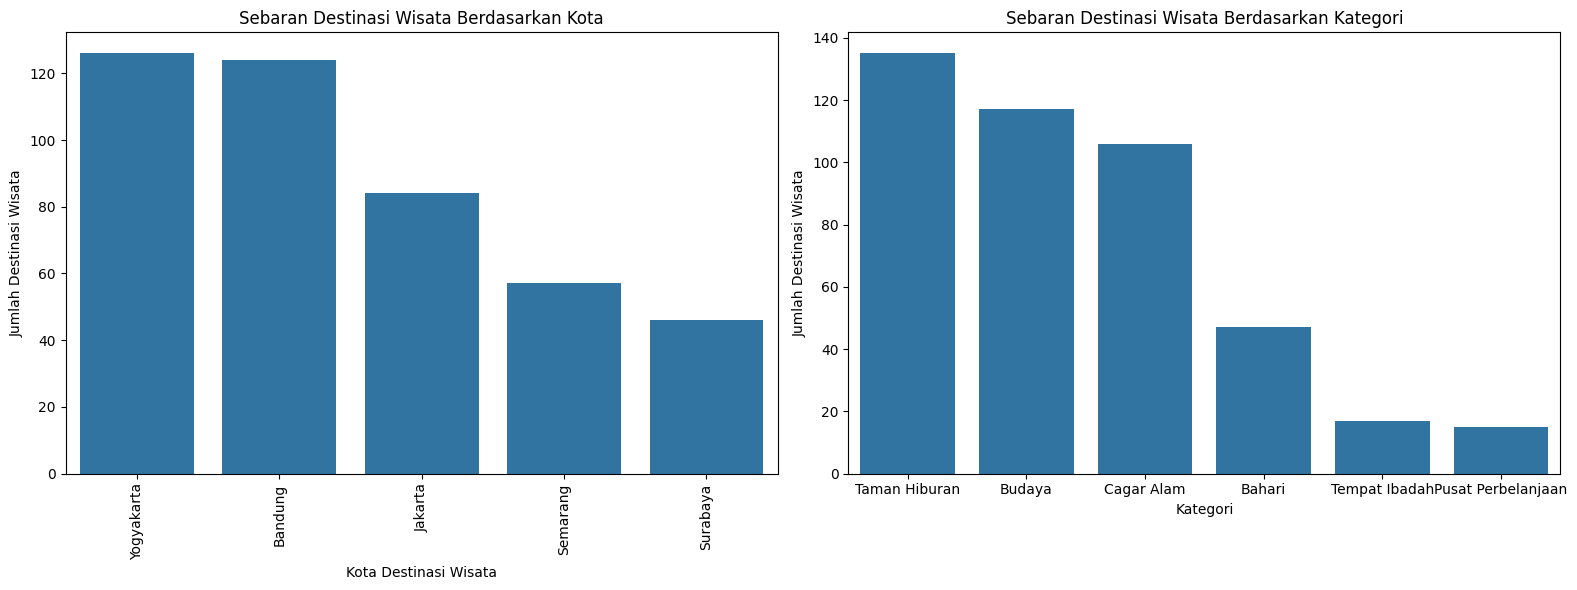

In [17]:
# Buat subplots dengan 1 baris dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Grafik 1: Sebaran Destinasi Wisata Berdasarkan Kota ---
sns.countplot(
    x='City',
    data=places,
    order=places['City'].value_counts().index,
    ax=axes[0]
)
axes[0].set_title('Sebaran Destinasi Wisata Berdasarkan Kota')
axes[0].set_xlabel('Kota Destinasi Wisata')
axes[0].set_ylabel('Jumlah Destinasi Wisata')
axes[0].tick_params(axis='x', rotation=90)

# --- Grafik 2: Sebaran Destinasi Wisata Berdasarkan Kategori ---
# Urutkan usia secara numerik
sns.countplot(
    x='Category',
    data=places,
    order=places['Category'].value_counts().index,
    ax=axes[1]
)
axes[1].set_title('Sebaran Destinasi Wisata Berdasarkan Kategori')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Jumlah Destinasi Wisata')

# Tampilkan kedua grafik
plt.tight_layout()
# Simpan Grafik
plt.savefig('sebaran_destinasi.png', dpi=300, bbox_inches='tight')

plt.show()

Grafik ini merupakan sebaran destinasi wisata berdasarkan kota dan kategorinya. Terlihat data tidak seimbang dari setiap kotanya maupun dari setiap kategorinya.

# Data Preprocessing

In [ ]:
reader = Reader(rating_scale=(1,5)) # rating scale range
data = Dataset.load_from_df(ratings[['User_Id', 'Place_Id', 'Place_Ratings']], reader)

Fungsi ini digunakan untuk menyiapkan data rating pengguna terhadap tempat agar bisa digunakan dalam algoritma sistem rekomendasi menggunakan library Surprise. Jadi artinya format dataset sebelumnya diubah menjadi format dataset internal Surprise.

In [ ]:
# Split the data into training and testing sets
trainset, testset = train_test_split(data, test_size=0.3)

Membagi dataset menjadi train set dan test set dengan proporsi 70% untuk train set dan 30% untuk test set.

# Model Development

## Inisialisasi model menggunakan algoritma Slope One

In [ ]:
# Membuat model Slope One
model_slope_one = SlopeOne()

# Melatih model Slope One pada data training
model_slope_one.fit(trainset)

Melatih model menggunakan Algoritma Slope One

## Inisialisasi model menggunakan algoritma NMF

In [ ]:
# Define parameter grid untuk mode
param_grid = {
     'n_factors': [10, 20, 50, 100],
    'n_epochs': [20, 50, 100],
    'reg_pu': [0.02, 0.05, 0.001],
    'reg_qi': [0.02, 0.05, 0.001]
}

# Grid search untuk NMF
gs_nmf = GridSearchCV(NMF, param_grid, measures=['rmse', 'mae'], cv=5, joblib_verbose=1)
gs_nmf.fit(data)

# Lihat hasil terbaik
print("Best RMSE Score:", gs_nmf.best_score['rmse'])
print("Best Params:", gs_nmf.best_params['rmse'])

# Model terbaik
best_model = gs_nmf.best_estimator['rmse']

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   18.9s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:  1.2min


Best RMSE Score: 1.5243776667332192
Best Params: {'n_factors': 100, 'n_epochs': 50, 'reg_pu': 0.05, 'reg_qi': 0.05}


Kode ini menjalankan Grid Search Cross Validation untuk menemukan parameter terbaik dari algoritma rekomendasi NMF menggunakan library Surprise. Tujuannya adalah untuk mengoptimalkan performa model rekomendasi berdasarkan metrik error seperti RMSE (Root Mean Squared Error) dan MAE (Mean Absolute Error). Hasil dari Grid Search ini nantinya digunakan sebagai parameter dalam melatih model NMF.

In [ ]:
# Use the SVD algorithm to train the model
model_NMF = NMF(n_factors=100, n_epochs=50, reg_pu=0.05, reg_qi=0.05)
model_NMF.fit(trainset)

Melatih model dengan algoritma NMF yang tersedia pada library Surprise dengan paramater terbaik.

## Inisialisasi model menggunakan algoritma Co Clustering

In [ ]:
# Definisikan parameter grid untuk Co-Clustering
param_grid_co_clustering = {
    'n_cltr_u': [1, 3, 5, 10],
    'n_cltr_i': [1, 3, 5, 10],
    'n_epochs': [10, 20, 50]
}

# Melakukan Grid Search untuk Co-Clustering
gs_co_clustering = GridSearchCV(CoClustering, param_grid_co_clustering, measures=['rmse', 'mae'], cv=5)
gs_co_clustering.fit(data)

# Mendapatkan model terbaik dan parameter terbaik untuk Co-Clustering
best_co_clustering_model = gs_co_clustering.best_estimator['rmse']
best_co_clustering_params = gs_co_clustering.best_params['rmse']

print("Best Params for Co-Clustering:", best_co_clustering_params)
print("Best RMSE for Co-Clustering:", gs_co_clustering.best_score['rmse'])


Best Params for Co-Clustering: {'n_cltr_u': 1, 'n_cltr_i': 1, 'n_epochs': 10}
Best RMSE for Co-Clustering: 1.4382341137479024


Kode ini menjalankan Grid Search Cross Validation untuk menemukan parameter terbaik dari algoritma rekomendasi Co Clustering menggunakan library Surprise. Tujuannya adalah untuk mengoptimalkan performa model rekomendasi berdasarkan metrik error seperti RMSE (Root Mean Squared Error) dan MAE (Mean Absolute Error). Hasil dari Grid Search ini nantinya digunakan sebagai parameter dalam melatih model Co Clustering.

In [ ]:
model_co_clustering = CoClustering(n_cltr_u=1, n_cltr_i=1, n_epochs=10)
model_co_clustering.fit(trainset)

Melatih model dengan menggunakan Algoritma Co Clustering

# Model Evaluasi

In [ ]:
metrics = pd.DataFrame(columns=['Test_RMSE','Test_MAE', 'Precision@10', 'Recall@10'], index=['Slope_One', 'NMF', 'Co_Clustering'])

model_dict = {'Slope_One': model_slope_one, 'NMF': model_NMF, 'Co_Clustering': model_co_clustering}

Menginisialisasi dataframe metrics untuk menampung nilai dari metrics evaluasi sekaligus menyimpan model yang telah dilatih.

In [ ]:
def precision_recall_at_k(predictions, k=5, threshold=4.0):
    user_est_true = defaultdict(list)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = {}
    recalls = {}

    for uid, user_ratings in user_est_true.items():
        # Urutkan berdasarkan rating prediksi (descending)
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Hitung total item relevan (berdasarkan true_r)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Hitung item relevan dalam top-k (berdasarkan true_r)
        n_rec_k = sum((true_r >= threshold) for (_, true_r) in user_ratings[:k])

        # Precision@k: proporsi relevan dalam top-k
        precisions[uid] = n_rec_k / k

        # Recall@k: proporsi item relevan yang tercover
        recalls[uid] = n_rec_k / n_rel if n_rel != 0 else 0

    # Rata-rata semua user
    avg_precision = sum(precisions.values()) / len(precisions)
    avg_recall = sum(recalls.values()) / len(recalls)

    return avg_precision, avg_recall

Fungsi untuk menghitung precision@k dan recall@k

In [ ]:
for name, model in model_dict.items():
    # Melakukan prediksi pada data test
    pred_test = model.test(testset)
    precision, recall = precision_recall_at_k(pred_test, k=10, threshold=4)

    # Menghitung RMSE dan MAE
    metrics.loc[name, 'Test_RMSE'] = accuracy.rmse(pred_test, verbose=False)
    metrics.loc[name, 'Test_MAE'] = accuracy.mae(pred_test, verbose=False)
    metrics.loc[name, 'Precision@10'] = precision
    metrics.loc[name, 'Recall@10'] = recall

metrics


,Test_RMSE,Test_MAE,Precision@10,Recall@10
Slope_One,1.531999,1.285102,0.366667,0.892593
NMF,1.514674,1.2792,0.369333,0.901082
Co_Clustering,1.4394,1.230725,0.367667,0.893437


Melakukan testing model sekaligus menghitung metrics evaluasi untuk RMSE, MAE, Precision@k dan Recall@k, yang kemudian disimpan dalam dataframe metrics.

# Inferensi Model

In [ ]:
def get_top_highest_rated_places(user_id):
    user_place_ids = ratings[ratings['User_Id'] == user_id]

    highest_rated_places = user_place_ids.merge(places[['Place_Id', 'Place_Name', 'Category']], on='Place_Id').sort_values(by='Place_Ratings', ascending=False).head(5)
    print('Showing recommendations for users: {}'.format(user_id))
    print('====' * 9)
    print('Destination with high ratings from user')
    print('----' * 8)
    for row in highest_rated_places.itertuples():
        print(row.Place_Id, ':', row.Place_Name, ':', row.Category)

Fungsi diatas untuk mengambil rating tertinggi yang diberikan pengguna terhadap destinasi wisata. Daftar tersebut diambil sebagai acuan untuk membandingkan antara destinasi yang relevan dengan destinasi yang direkomendasikan.

In [ ]:
def get_top_n_recommendations(name, model, user_id, n=10):
    # Dapatkan semua item yang belum di-rating oleh user
    testset = trainset.build_anti_testset()
    testset = filter(lambda x: x[0] == user_id, testset)

    # Prediksi rating untuk semua item
    predictions = model.test(testset)

    # Urutkan prediksi berdasarkan rating tertinggi
    predictions.sort(key=lambda x: x.est, reverse=True)

    # Ambil top N rekomendasi
    top_n = predictions[:n]

    # Konversi ke DataFrame
    recommendations_df = pd.DataFrame([{
        'Place_Id': pred.iid,
    } for pred in top_n])

    recommendations_df = recommendations_df.merge(places[['Place_Id', 'Place_Name', 'Category']], on='Place_Id')
    print('----' * 8)
    print('Top 10 Rekomendasi menggunakan Model', name)
    print('----' * 8)
    for row in recommendations_df.itertuples():
        print(row.Place_Id, ':', row.Place_Name, ':', row.Category)


fungsi diatas untuk mengambil Top 10 rekomendasi  destinasi wisata berdasarkan User_Id.

In [ ]:
user_id = 211
get_top_highest_rated_places(user_id)
for name, model in model_dict.items():
  get_top_n_recommendations(name, model, user_id)

Showing recommendations for users: 211
Destination with high ratings from user
--------------------------------
202 : Pantai Ngandong : Bahari
31 : Wisata Alam Mangrove Angke : Cagar Alam
37 : Bumi Perkemahan Cibubur : Taman Hiburan
49 : Galeri Indonesia Kaya : Budaya
125 : Alun-alun Utara Keraton Yogyakarta : Budaya
--------------------------------
Top 10 Rekomendasi menggunakan Model Slope_One
--------------------------------
138 : Jogja Exotarium : Taman Hiburan
52 : Kampung Cina : Budaya
253 : Selasar Sunaryo Art Space : Taman Hiburan
160 : Pasar Kebon Empring Bintaran : Pusat Perbelanjaan
254 : Teras Cikapundung BBWS : Taman Hiburan
189 : Pantai Nguluran : Bahari
32 : Setu Babakan : Budaya
392 : Ekowisata Mangrove Wonorejo : Cagar Alam
51 : Jakarta Planetarium : Taman Hiburan
237 : Panghegar Waterboom Bandung : Taman Hiburan
--------------------------------
Top 10 Rekomendasi menggunakan Model NMF
--------------------------------
401 : Taman Keputran : Taman Hiburan
51 : Jakarta P